## Step 2: Aggregate Master Grid & Coverage Analysis

The master grid contains one row per `(h3_index, month, species)`. Before we can train a time series model we need to collapse this down to one row per `(h3_index, month)` — a single numerical snapshot of each hex cell each month. We then analyse how many months of data each hex cell has, because cells with very sparse history cannot be used for training.

In [2]:
!pip install duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 34.2 MB/s  0:00:00m0:00:0100:01


In [1]:
import ray
import duckdb
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging

my_env = {"pip": ["duckdb", "pandas<3.0.0", "pyarrow", "h3", "matplotlib", "torch"]}
MY_NAMESPACE = "OBIS_TEST"

In [2]:
import os
import logging
import ray

# 1. Block the submodule at the environment level
os.environ["RAY_LOG_LEVEL"] = "error" 

# 2. Add a global filter to the ROOT logger
class RayCleanerFilter(logging.Filter):
    def filter(self, record):
        # This catches the exact string from your warning
        msg = record.getMessage()
        return "PlacementGroupCleaner" not in msg and "Ray Train Controller" not in msg

# Apply to all possible loggers that handle remote streams
logging.getLogger().addFilter(RayCleanerFilter())
logging.getLogger("ray").addFilter(RayCleanerFilter())
logging.getLogger("ray.train").addFilter(RayCleanerFilter())

if ray.is_initialized():
    ray.shutdown()

# 3. Use the logging_level parameter in init
ray.init(
    address="auto", 
    runtime_env=my_env, 
    namespace=MY_NAMESPACE,
    logging_level=logging.ERROR,
    ignore_reinit_error=True # <--- ADD THIS
)

Python version:,3.11.6
Ray version:,2.54.0
Dashboard:,http://10.10.1.98:8265


### 2.1 Aggregate: (h3, month, species) → (h3, month)

For each monthly partition file we run a `GROUP BY h3_index` query that sums all numerical signals and drops the species columns. Processing one partition at a time keeps memory usage low — we never load more than one month of data into a worker at once.

The result is written to `/mnt/shared_data/finflow/timeseries_grid/` as one Parquet file per month.

In [3]:
@ray.remote
class AggregationWorker:
    def run(self, partition_paths: list, output_path: str):
        import duckdb, os
        import pandas as pd

        os.makedirs(output_path, exist_ok=True)

        for i, path in enumerate(partition_paths):
            # Month comes from folder name: best_time_marker=YYYY-MM
            month = os.path.basename(os.path.dirname(path)).split("=")[1]

            con = duckdb.connect()
            df = con.execute(f"""
                SELECT
                    h3_index,
                    '{month}'                               AS year_month,
                    SUM(COALESCE(total_sighting_count, 0))  AS total_sighting_count,
                    SUM(COALESCE(total_fishing_hours,  0))  AS total_fishing_hours,
                    SUM(COALESCE(boat_ping_count,      0))  AS boat_ping_count
                FROM read_parquet('{path}')
                WHERE h3_index IS NOT NULL
                GROUP BY h3_index
            """).df()

            out_file = os.path.join(output_path, f"{month}.parquet")
            df.to_parquet(out_file, index=False)
            print(f"[{i+1}/{len(partition_paths)}] {month} → {len(df):,} hex cells")

        return f"Done! {len(partition_paths)} partitions written to {output_path}"

In [4]:
INPUT_PATTERN = "/mnt/shared_data/finflow/ocean_master_grid/best_time_marker=*/*.parquet"
OUTPUT_PATH   = "/mnt/shared_data/finflow/timeseries_grid/"

partition_files = sorted(glob.glob(INPUT_PATTERN))
print(f"Partitions found: {len(partition_files)}")

worker = AggregationWorker.options(name="Agg_Worker", get_if_exists=True).remote()
result = ray.get(worker.run.remote(partition_files, OUTPUT_PATH))
print(result)

Partitions found: 168
(AggregationWorker pid=67601, ip=10.10.4.23) [1/168] 2012-01 → 1,040,026 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [2/168] 2012-02 → 973,634 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [3/168] 2012-03 → 871,988 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [4/168] 2012-04 → 1,146,577 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [5/168] 2012-05 → 1,221,210 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [6/168] 2012-06 → 1,176,199 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [7/168] 2012-07 → 1,355,025 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [8/168] 2012-08 → 1,389,047 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [9/168] 2012-09 → 1,366,813 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [10/168] 2012-10 → 1,398,753 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [11/168] 2012-11 → 1,488,542 hex cells
(AggregationWorker pid=67601, ip=10.10.4.23) [12/168] 2012-12 → 1,5

### 2.2 Coverage Analysis

We need to count how many months each hex cell appears in across all 168 aggregated files. This query touches tens of millions of unique hex cells — too large to run in the local kernel. We send it to a Ray actor on the cluster instead, save the result to disk, and only pull back a small summary.

In [5]:
# memory=20GB tells Ray's scheduler: only place this actor on a node with 20GB free
@ray.remote(memory=20 * 1024**3)
class CoverageWorker:
    def run(self, timeseries_path: str, output_path: str):
        import duckdb, glob, os
        import pandas as pd

        os.makedirs('/tmp/duckdb_coverage_tmp', exist_ok=True)
        files = sorted(glob.glob(timeseries_path + "/*.parquet"))
        print(f"Scanning {len(files)} aggregated files in batches...")

        # Cap DuckDB memory so Ray's OOM killer doesn't intervene
        con = duckdb.connect(config={
            'temp_directory': '/tmp/duckdb_coverage_tmp',
            'memory_limit': '18GB',
            'threads': 2,  # Reduced from 4
        })

        # --- Pass 1: process 14 files at a time (reduced from 28), write partial counts ---
        BATCH_SIZE = 14
        partial_files = []
        batches = [files[i:i+BATCH_SIZE] for i in range(0, len(files), BATCH_SIZE)]

        for idx, batch in enumerate(batches):
            partial_out = f'/tmp/duckdb_coverage_tmp/partial_{idx}.parquet'
            
            # Build file list string for DuckDB
            file_list = '[' + ', '.join(f"'{f}'" for f in batch) + ']'
            
            con.execute(f'''
                COPY (
                    SELECT h3_index, COUNT(*) AS partial_count
                    FROM read_parquet({file_list})
                    WHERE h3_index IS NOT NULL
                    GROUP BY h3_index
                ) TO '{partial_out}' (FORMAT PARQUET)
            ''')
            partial_files.append(partial_out)
            print(f"  Batch {idx+1}/{len(batches)} done ({len(batch)} months)")

        # --- Pass 2: merge partial counts into final coverage file ---
        print("Merging partial counts...")
        partial_list = '[' + ', '.join(f"'{f}'" for f in partial_files) + ']'
        con.execute(f'''
            COPY (
                SELECT h3_index, SUM(partial_count) AS months_with_data
                FROM read_parquet({partial_list})
                GROUP BY h3_index
            ) TO '{output_path}' (FORMAT PARQUET)
        ''')

        # Return lightweight summary only
        summary = con.execute(f'''
            SELECT
                COUNT(*)                                     AS total_hex_cells,
                SUM(CASE WHEN months_with_data >= 12  THEN 1 ELSE 0 END) AS ge_12,
                SUM(CASE WHEN months_with_data >= 24  THEN 1 ELSE 0 END) AS ge_24,
                SUM(CASE WHEN months_with_data >= 36  THEN 1 ELSE 0 END) AS ge_36,
                SUM(CASE WHEN months_with_data >= 48  THEN 1 ELSE 0 END) AS ge_48,
                SUM(CASE WHEN months_with_data >= 60  THEN 1 ELSE 0 END) AS ge_60,
                SUM(CASE WHEN months_with_data >= 100 THEN 1 ELSE 0 END) AS ge_100,
                SUM(CASE WHEN months_with_data >= 150 THEN 1 ELSE 0 END) AS ge_150,
                SUM(CASE WHEN months_with_data = 168  THEN 1 ELSE 0 END) AS ge_168
            FROM read_parquet('{output_path}')
        ''').df()

        # Clean up temp partials
        for f in partial_files:
            os.remove(f)

        return summary.to_dict(orient='records')[0]

In [6]:
TIMESERIES_PATH  = "/mnt/shared_data/finflow/timeseries_grid"
COVERAGE_OUTPUT  = "/mnt/shared_data/finflow/coverage.parquet"

print("Launching coverage worker on cluster...")
cov_worker = CoverageWorker.options(name="Coverage_Worker", get_if_exists=True).remote()
summary = ray.get(cov_worker.run.remote(TIMESERIES_PATH, COVERAGE_OUTPUT))

total = summary['total_hex_cells']
print(f"\nTotal unique hex cells: {total:,}\n")
print(f"Cells surviving at each threshold:")
for key, label in [('ge_12','12'),('ge_24','24'),('ge_36','36'),('ge_48','48'),
                    ('ge_60','60'),('ge_100','100'),('ge_150','150'),('ge_168','168')]:
    n = summary[key]
    print(f"  >= {label:>3} months : {n:>10,}  ({n/total*100:.1f}%)")

Launching coverage worker on cluster...
(CoverageWorker pid=12799) Scanning 168 aggregated files in batches...
(CoverageWorker pid=12799)   Batch 1/12 done (14 months)
(CoverageWorker pid=12799)   Batch 2/12 done (14 months)
(CoverageWorker pid=12799)   Batch 3/12 done (14 months)
(CoverageWorker pid=12799)   Batch 4/12 done (14 months)
(CoverageWorker pid=12799)   Batch 5/12 done (14 months)
(CoverageWorker pid=12799)   Batch 6/12 done (14 months)
(CoverageWorker pid=12799)   Batch 7/12 done (14 months)
(CoverageWorker pid=12799)   Batch 8/12 done (14 months)
(CoverageWorker pid=12799)   Batch 9/12 done (14 months)
(CoverageWorker pid=12799)   Batch 10/12 done (14 months)
(CoverageWorker pid=12799)   Batch 11/12 done (14 months)
(CoverageWorker pid=12799)   Batch 12/12 done (14 months)
(CoverageWorker pid=12799) Merging partial counts...

Total unique hex cells: 40,533,495

Cells surviving at each threshold:
  >=  12 months : 9,579,191.0  (23.6%)
  >=  24 months : 4,786,634.0  (11.8%)

### 2.3 Coverage Histogram

We pull only a histogram bucketing (not the raw millions of rows) back into the kernel for plotting.

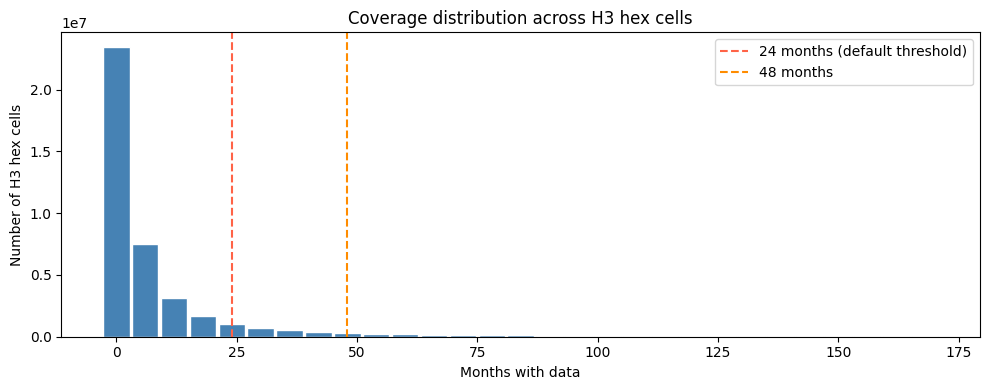

In [7]:
# Pull only histogram buckets — tiny data transfer to kernel
hist_df = duckdb.connect().execute(f"""
    SELECT
        FLOOR(months_with_data / 6) * 6 AS bucket_start,
        COUNT(*) AS hex_count
    FROM read_parquet('{COVERAGE_OUTPUT}')
    GROUP BY bucket_start
    ORDER BY bucket_start
""").df()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hist_df['bucket_start'], hist_df['hex_count'], width=5.5, color='steelblue', edgecolor='white')
ax.axvline(24, color='tomato',     linestyle='--', label='24 months (default threshold)')
ax.axvline(48, color='darkorange', linestyle='--', label='48 months')
ax.set_xlabel('Months with data')
ax.set_ylabel('Number of H3 hex cells')
ax.set_title('Coverage distribution across H3 hex cells')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Filter to Well-Covered Hex Cells

Based on the histogram, pick `MIN_MONTHS`. The default is 24 (two full seasonal cycles). The filtering runs on the cluster and saves a small allowlist parquet — all future steps use only these hex cells.

In [8]:
MIN_MONTHS = 36  # adjust after reviewing histogram

@ray.remote
def save_qualified_hexes(coverage_path: str, output_path: str, min_months: int):
    import duckdb
    con = duckdb.connect()
    con.execute(f"""
        COPY (
            SELECT h3_index, months_with_data
            FROM read_parquet('{coverage_path}')
            WHERE months_with_data >= {min_months}
            ORDER BY months_with_data DESC
        ) TO '{output_path}' (FORMAT PARQUET)
    """)
    count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{output_path}')").fetchone()[0]
    return count

n = ray.get(save_qualified_hexes.remote(
    COVERAGE_OUTPUT,
    "/mnt/shared_data/finflow/qualified_hexes.parquet",
    MIN_MONTHS
))
print(f"Qualified hex cells (>= {MIN_MONTHS} months): {n:,}")
print("Saved → /mnt/shared_data/finflow/qualified_hexes.parquet")

Qualified hex cells (>= 36 months): 3,030,299
Saved → /mnt/shared_data/finflow/qualified_hexes.parquet


## Step 3: Pivot into Time Series Matrix (on Cluster)

Load qualified hex cells and reshape timeseries data into a matrix format.
**Important**: This runs on the cluster via Ray to avoid crashing the local kernel with huge DataFrames.
- Rows: hex cells (from qualified_hexes.parquet)
- Columns: months (YYYY-MM sorted chronologically)
- Values: total_sighting_count, total_fishing_hours, boat_ping_count

**Memory Strategy**: Processes in batches of 10,000 hex cells at a time to stay within limits.

In [ ]:
@ray.remote(memory=30 * 1024**3)  # Request 30GB from Ray scheduler
class PivotWorker:
    def run(self, timeseries_path: str, qualified_hexes_path: str, output_dir: str):
        '''Pivot timeseries data on the cluster in batches to manage memory'''
        import duckdb
        import os
        
        os.makedirs(output_dir, exist_ok=True)
        con = duckdb.connect(config={
            'temp_directory': '/tmp/duckdb_pivot_tmp',
            'memory_limit': '25GB',
            'threads': 4,
        })
        os.makedirs('/tmp/duckdb_pivot_tmp', exist_ok=True)
        
        # Step 1: Get count and month list (lightweight)
        total_hexes = con.execute(f"""
            SELECT COUNT(DISTINCT h3_index) as n FROM read_parquet('{qualified_hexes_path}')
        """).df()['n'][0]
        
        months_sorted = con.execute(f"""
            SELECT DISTINCT year_month FROM read_parquet('{timeseries_path}/*.parquet')
            ORDER BY year_month
        """).df()['year_month'].tolist()
        
        print(f"Processing {total_hexes:,} qualified hex cells over {len(months_sorted)} months...")
        
        # Step 2: Process in batches of 10k hex cells to avoid OOM
        metrics = ['total_sighting_count', 'total_fishing_hours', 'boat_ping_count']
        BATCH_SIZE = 10000
        
        # Get sorted list of all qualified hex IDs
        all_hex_ids = con.execute(f"""
            SELECT DISTINCT h3_index FROM read_parquet('{qualified_hexes_path}')
            ORDER BY h3_index
        """).df()['h3_index'].tolist()
        
        print(f"Processing {total_hexes:,} hex cells in {(total_hexes // BATCH_SIZE) + 1} batches...")
        
        # Initialize partial outputs
        partial_outputs = {metric: [] for metric in metrics}
        
        for batch_idx in range(0, total_hexes, BATCH_SIZE):
            batch_end = min(batch_idx + BATCH_SIZE, total_hexes)
            batch_hex_ids = all_hex_ids[batch_idx:batch_end]
            batch_hex_list = ','.join(repr(h) for h in batch_hex_ids)
            
            print(f"  Batch {batch_idx//BATCH_SIZE + 1}: processing hex cells {batch_idx:,}–{batch_end:,}")
            
            for metric in metrics:
                # Query: select h3_index + all months' data for this batch
                pivot_query = f"""
                    SELECT 
                        h3_index,
                        {', '.join([f"COALESCE(MAX(CASE WHEN year_month = '{m}' THEN {metric} END), 0) as '{m}'" for m in months_sorted])}
                    FROM read_parquet('{timeseries_path}/*.parquet')
                    WHERE h3_index IN ({batch_hex_list})
                    GROUP BY h3_index
                """
                
                partial_file = f'/tmp/duckdb_pivot_tmp/partial_{metric}_batch_{batch_idx // BATCH_SIZE}.parquet'
                con.execute(f"COPY ({pivot_query}) TO '{partial_file}' (FORMAT PARQUET)")
                partial_outputs[metric].append(partial_file)
        
        # Step 3: Merge all batch results
        print("\nMerging batch results...")
        for metric in metrics:
            partial_files = partial_outputs[metric]
            partial_list = '[' + ', '.join(f"'{f}'" for f in partial_files) + ']'
            
            output_path = f'{output_dir}/timeseries_matrix_{metric}.parquet'
            con.execute(f"""
                COPY (
                    SELECT * FROM read_parquet({partial_list})
                    ORDER BY h3_index
                ) TO '{output_path}' (FORMAT PARQUET)
            """)
            
            # Clean up partials
            for f in partial_files:
                os.remove(f)
            
            print(f"✓ {metric}: merged to {output_path}")
        
        # Save month list for next step
        with open(f'{output_dir}/months.txt', 'w') as f:
            for m in months_sorted:
                f.write(m + '\n')
        
        return {
            'n_hexes': total_hexes,
            'n_months': len(months_sorted),
            'date_range': f"{months_sorted[0]} to {months_sorted[-1]}"
        }

# Launch on cluster with explicit memory request
print("Launching PivotWorker on cluster (requesting 30GB memory)...")
pivot_worker = PivotWorker.options(name="Pivot_Worker", get_if_exists=True).remote()
result = ray.get(pivot_worker.run.remote(
    '/mnt/shared_data/finflow/timeseries_grid',
    '/mnt/shared_data/finflow/qualified_hexes.parquet',
    '/mnt/shared_data/finflow/timeseries_matrices'
))

print(f"\n✓ Pivot complete:")
print(f"  Hex cells: {result['n_hexes']:,}")
print(f"  Months: {result['n_months']}")
print(f"  Date range: {result['date_range']}")

## Step 4: Time-Based Train/Val/Test Split (on Cluster)

Divide the time series chronologically (not randomly) to avoid data leakage.
- **Train**: 2012-01 to 2019-12 (8 years pre-event)
- **Val**: 2020-01 to 2021-12 (2 years COVID + recovery)
- **Test**: 2022-01 to 2025-12 (4 years post-event)

In [13]:
@ray.remote(memory=20 * 1024**3)  # Request 20GB for splitting
class TrainValTestSplitter:
    def run(self, matrix_dir: str, output_dir: str):
        '''Split pivoted matrices by time on cluster'''
        import duckdb
        import os
        
        os.makedirs(output_dir, exist_ok=True)
        con = duckdb.connect(config={
            'memory_limit': '18GB',
            'threads': 2,
        })
        
        # Read month list
        with open(f'{matrix_dir}/months.txt', 'r') as f:
            months_sorted = [line.strip() for line in f]
        
        # Define splits
        train_end = '2019-12'
        val_end = '2021-12'
        test_end = '2025-12'
        
        train_months = [m for m in months_sorted if m <= train_end]
        val_months = [m for m in months_sorted if train_end < m <= val_end]
        test_months = [m for m in months_sorted if val_end < m <= test_end]
        
        print(f"Train: {len(train_months)} months ({train_months[0]} → {train_months[-1]})")
        print(f"Val:   {len(val_months)} months ({val_months[0]} → {val_months[-1]})")
        print(f"Test:  {len(test_months)} months ({test_months[0]} → {test_months[-1]})")
        
        # Process each metric
        metrics = ['total_sighting_count', 'total_fishing_hours', 'boat_ping_count']
        
        for metric in metrics:
            matrix_file = f'{matrix_dir}/timeseries_matrix_{metric}.parquet'
            
            # Select train columns
            train_col_list = ', '.join([f'"{m}"' for m in train_months])
            con.execute(f"""
                COPY (
                    SELECT h3_index, {train_col_list}
                    FROM read_parquet('{matrix_file}')
                ) TO '{output_dir}/train_{metric}.parquet' (FORMAT PARQUET)
            """)
            
            # Select val columns
            val_col_list = ', '.join([f'"{m}"' for m in val_months])
            con.execute(f"""
                COPY (
                    SELECT h3_index, {val_col_list}
                    FROM read_parquet('{matrix_file}')
                ) TO '{output_dir}/val_{metric}.parquet' (FORMAT PARQUET)
            """)
            
            # Select test columns
            test_col_list = ', '.join([f'"{m}"' for m in test_months])
            con.execute(f"""
                COPY (
                    SELECT h3_index, {test_col_list}
                    FROM read_parquet('{matrix_file}')
                ) TO '{output_dir}/test_{metric}.parquet' (FORMAT PARQUET)
            """)
            
            print(f"✓ Split {metric}")
        
        return {
            'train_months': len(train_months),
            'val_months': len(val_months),
            'test_months': len(test_months),
            'metrics': metrics
        }

# Launch on cluster
print("Launching TrainValTestSplitter on cluster (requesting 20GB memory)...")
splitter = TrainValTestSplitter.options(name="Splitter_Worker", get_if_exists=True).remote()
result = ray.get(splitter.run.remote(
    '/mnt/shared_data/finflow/timeseries_matrices',
    '/mnt/shared_data/finflow/train_val_test_splits'
))

print(f"\n✓ Train/Val/Test split complete:")
print(f"  Train: {result['train_months']} months")
print(f"  Val:   {result['val_months']} months")
print(f"  Test:  {result['test_months']} months")

Launching TrainValTestSplitter on cluster (requesting 20GB memory)...
(TrainValTestSplitter pid=4884, ip=10.10.1.34) Train: 96 months (2012-01 → 2019-12)
(TrainValTestSplitter pid=4884, ip=10.10.1.34) Val:   24 months (2020-01 → 2021-12)
(TrainValTestSplitter pid=4884, ip=10.10.1.34) Test:  48 months (2022-01 → 2025-12)
(TrainValTestSplitter pid=4884, ip=10.10.1.34) ✓ Split total_sighting_count
(TrainValTestSplitter pid=4884, ip=10.10.1.34) ✓ Split total_fishing_hours
(TrainValTestSplitter pid=4884, ip=10.10.1.34) ✓ Split boat_ping_count

✓ Train/Val/Test split complete:
  Train: 96 months
  Val:   24 months
  Test:  48 months


## Step 5: Train LSTM Forecaster on GPU UNI (FISHING)

Train a multi-output LSTM to predict the next month's fishing activity.
- Input: 12 months of historical data
- Output: predictions for next month
- Loss: MSE on held-out validation set

In [1]:
%%writefile train_lstm.py
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import ray
from ray.train import ScalingConfig, RunConfig, Checkpoint
from ray.train.torch import TorchTrainer
import ray.train.torch
from tqdm import tqdm

# 1. INITIALIZE RAY INSIDE THE SCRIPT
ray.init(address="auto", namespace="OBIS_TEST", ignore_reinit_error=True)

model_output_path = '/mnt/shared_data/finflow/lstm_models'
train_val_dir = '/mnt/shared_data/finflow/train_val_test_splits'
os.makedirs(model_output_path, exist_ok=True)

# ==========================================
# 2. DISTRIBUTED DATA PIPELINE
# ==========================================
print("Setting up distributed data pipelines...")

class FastSequenceGenerator:
    def __init__(self, lookback):
        self.lookback = lookback

    def __call__(self, batch: pd.DataFrame) -> dict:
        cols = [c for c in batch.columns if c not in ['h3_index', 'index']]
        data = batch[cols].values.astype(np.float32)
        
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(data, window_shape=self.lookback + 1, axis=1)
        windows = windows.reshape(-1, self.lookback + 1)
        
        return {"X": windows[:, :-1], "y": windows[:, -1]}

train_ds = ray.data.read_parquet('/mnt/shared_data/finflow/precomputed_sequences')
val_ds = ray.data.read_parquet(f'{train_val_dir}/val_total_fishing_hours.parquet')
val_ds = val_ds.map_batches(FastSequenceGenerator(12), batch_format="pandas")

# ==========================================
# 3. DISTRIBUTED TRAINING WORKER FUNCTION
# ==========================================
def train_loop_per_worker(config):
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Linear(64, 1)
            )
        
        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            last_hidden = lstm_out[:, -1, :]
            out = self.fc(last_hidden)
            return out.squeeze()
            
    model = LSTMModel(input_size=1, hidden_size=128, num_layers=2, dropout=0.2)
    
    model = torch.compile(model)
    model = ray.train.torch.prepare_model(model)
    
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_shard = ray.train.get_dataset_shard("train")
    val_shard = ray.train.get_dataset_shard("val")
    
    epochs = config["epochs"]
    batch_size = config["batch_size"]
    world_rank = ray.train.get_context().get_world_rank()
    
    best_val_loss = float('inf')
    patience, patience_counter = 8, 0
    history = {'epochs': [], 'train_loss': [], 'val_loss': []}
    
    if world_rank == 0:
        epoch_iterator = tqdm(range(epochs), desc="Training on 4 GPUs (Turbo)")
    else:
        epoch_iterator = range(epochs)
        
    for epoch in epoch_iterator:
        # --- Train ---
        model.train()
        train_loss, train_batches = 0, 0
        
        for batch in train_shard.iter_torch_batches(batch_size=batch_size, local_shuffle_buffer_size=10000):
            X_batch = batch["X"].float().unsqueeze(-1)
            y_batch = batch["y"].float()

            X_batch = torch.log1p(X_batch) 
            y_batch = torch.log1p(y_batch)

            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                pred = model(X_batch)
                loss = loss_fn(pred, y_batch)
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
            
        train_loss /= max(train_batches, 1)
        
        # --- Validation ---
        model.eval()
        val_loss, val_batches = 0, 0
        with torch.no_grad():
            for batch in val_shard.iter_torch_batches(batch_size=batch_size):
                X_val_batch = batch["X"].float().unsqueeze(-1)
                y_val_batch = batch["y"].float()

                X_val_batch = torch.log1p(X_val_batch)
                y_val_batch = torch.log1p(y_val_batch)
                
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    val_pred = model(X_val_batch)
                    batch_loss = loss_fn(val_pred, y_val_batch)
                    
                val_loss += batch_loss.item()
                val_batches += 1
                
        val_loss /= max(val_batches, 1)
        
        if world_rank == 0:
            epoch_iterator.set_postfix({"Train Loss": f"{train_loss:.4f}", "Val Loss": f"{val_loss:.4f}"})
            history['epochs'].append(epoch + 1)
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            
            # ---> RENAMED TO V3 TO AVOID PERMISSION ERRORS <---
            pd.DataFrame(history).to_csv(f'{config["output_path"]}/training_history_v3.csv', index=False)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.module.state_dict(), f'{config["output_path"]}/best_model.pt')
            else:
                patience_counter += 1
                
        ray.train.report({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch + 1})
        
        if patience_counter >= patience:
            break

# ==========================================
# 4. LAUNCH TRAINER (DIRECTLY)
# ==========================================
print("Starting 4-GPU Distributed Trainer...")

scaling_config = ScalingConfig(num_workers=4, use_gpu=True)

trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config={
        "epochs": 150, 
        "batch_size": 1024,
        "output_path": model_output_path
    },
    datasets={"train": train_ds, "val": val_ds},
    scaling_config=scaling_config,
    run_config=RunConfig(storage_path="/mnt/shared_data/finflow/ray_results")
)

trainer.fit()

Writing train_lstm.py


In [4]:
from ray.job_submission import JobSubmissionClient
import os

# Connect to the dashboard API
client = JobSubmissionClient("http://10.10.1.98:8265")

# 1. Package the current directory (where train_lstm.py lives)
# and define the pip dependencies
my_env = {
    "working_dir": "./",  # <--- THIS IS THE CRITICAL FIX
    "pip": ["duckdb", "pandas<3.0.0", "pyarrow", "h3", "matplotlib", "torch"]
}

# 2. Submit the script
job_id = client.submit_job(
    entrypoint="python train_lstm.py",
    runtime_env=my_env
)

print(f"Job successfully submitted! Job ID: {job_id}")
print("You can completely close Jupyter, shut down your laptop, and go offline. The cluster owns this now.")

2026-05-04 00:35:56,492	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
2026-05-04 00:36:00,171	INFO dashboard_sdk.py:359 -- Uploading package gcs://_ray_pkg_88dbd5fbf1728554.zip.
2026-05-04 00:36:00,174	INFO packaging.py:691 -- Creating a file package for local module './'.


Job successfully submitted! Job ID: raysubmit_UbD7fRwcuczFnydT
You can completely close Jupyter, shut down your laptop, and go offline. The cluster owns this now.


In [ ]:
from ray.job_submission import JobSubmissionClient

# Connect to the dashboard API
client = JobSubmissionClient("http://10.10.1.98:8265")

# The exact submission ID you just got
submission_id = "raysubmit_UbD7fRwcuczFnydT"

# Ask the cluster for the status
status = client.get_job_status(submission_id)

print(f"Job Status: {status}")

# If you want to see the last few lines of the log to see what epoch it's on:
if status == "RUNNING":
    print("\n--- Last 5 lines of logs ---")
    # Grab all logs, split by line, and print the last 5
    logs = client.get_job_logs(submission_id)
    last_lines = logs.strip().split('\n')[-5:]
    for line in last_lines:
        print(line)

## Step 7: Train LSTM Forecaster on GPU MULTI (OBIS & MVB)

In [1]:
%%writefile train_lstm_multi.py
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import ray
from ray.train import ScalingConfig, RunConfig, Checkpoint
from ray.train.torch import TorchTrainer
import ray.train.torch
from tqdm import tqdm

# 1. INITIALIZE RAY INSIDE THE SCRIPT
ray.init(address="auto", namespace="OBIS_TEST", ignore_reinit_error=True)

model_output_path = '/mnt/shared_data/finflow/lstm_models_multi'
train_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_train'
val_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_val'
os.makedirs(model_output_path, exist_ok=True)

# ==========================================
# 2. DISTRIBUTED DATA PIPELINE
# ==========================================
print("Loading precomputed multivariate pipelines...")

# No on-the-fly generation needed! Just point and shoot.
train_ds = ray.data.read_parquet(train_dir)
val_ds = ray.data.read_parquet(val_dir)

# ==========================================
# 3. DISTRIBUTED TRAINING WORKER FUNCTION
# ==========================================
def train_loop_per_worker(config):
    class LSTMModel(nn.Module):
        # ---> UPGRADE: input_size=3 <---
        def __init__(self, input_size=3, hidden_size=128, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Linear(64, 1)
            )
        
        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            last_hidden = lstm_out[:, -1, :]
            out = self.fc(last_hidden)
            return out.squeeze()
            
    # Initialize Multivariate Model
    model = LSTMModel(input_size=3, hidden_size=128, num_layers=2, dropout=0.2)
    
    model = torch.compile(model)
    model = ray.train.torch.prepare_model(model)
    
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_shard = ray.train.get_dataset_shard("train")
    val_shard = ray.train.get_dataset_shard("val")
    
    epochs = config["epochs"]
    batch_size = config["batch_size"]
    world_rank = ray.train.get_context().get_world_rank()
    
    best_val_loss = float('inf')
    patience, patience_counter = 8, 0
    history = {'epochs': [], 'train_loss': [], 'val_loss': []}
    
    if world_rank == 0:
        epoch_iterator = tqdm(range(epochs), desc="Training MULTI on 4 GPUs")
    else:
        epoch_iterator = range(epochs)
        
    for epoch in epoch_iterator:
        # --- Train ---
        model.train()
        train_loss, train_batches = 0, 0
        
        for batch in train_shard.iter_torch_batches(batch_size=batch_size, local_shuffle_buffer_size=10000):
            # ---> UPGRADE: Snap the flat 36 floats back into (Batch, 12, 3) <---
            X_batch = batch["X"].float().view(-1, 12, 3)
            y_batch = batch["y"].float()

            X_batch = torch.log1p(X_batch) 
            y_batch = torch.log1p(y_batch)

            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                pred = model(X_batch)
                loss = loss_fn(pred, y_batch)
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
            
        train_loss /= max(train_batches, 1)
        
        # --- Validation ---
        model.eval()
        val_loss, val_batches = 0, 0
        with torch.no_grad():
            for batch in val_shard.iter_torch_batches(batch_size=batch_size):
                # ---> UPGRADE: Snap the flat 36 floats back into (Batch, 12, 3) <---
                X_val_batch = batch["X"].float().view(-1, 12, 3)
                y_val_batch = batch["y"].float()

                X_val_batch = torch.log1p(X_val_batch)
                y_val_batch = torch.log1p(y_val_batch)
                
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    val_pred = model(X_val_batch)
                    batch_loss = loss_fn(val_pred, y_val_batch)
                    
                val_loss += batch_loss.item()
                val_batches += 1
                
        val_loss /= max(val_batches, 1)
        
        if world_rank == 0:
            epoch_iterator.set_postfix({"Train Loss": f"{train_loss:.4f}", "Val Loss": f"{val_loss:.4f}"})
            history['epochs'].append(epoch + 1)
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            
            pd.DataFrame(history).to_csv(f'{config["output_path"]}/training_history_multi.csv', index=False)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.module.state_dict(), f'{config["output_path"]}/best_model_multi.pt')
            else:
                patience_counter += 1
                
        ray.train.report({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch + 1})
        
        if patience_counter >= patience:
            break

# ==========================================
# 4. LAUNCH TRAINER (DIRECTLY)
# ==========================================
print("Starting 4-GPU Distributed Trainer...")

scaling_config = ScalingConfig(num_workers=4, use_gpu=True)

trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config={
        "epochs": 150, 
        "batch_size": 1024,
        "output_path": model_output_path
    },
    datasets={"train": train_ds, "val": val_ds},
    scaling_config=scaling_config,
    run_config=RunConfig(storage_path="/mnt/shared_data/finflow/ray_results_multi")
)

trainer.fit()

Writing train_lstm_multi.py


In [2]:
from ray.job_submission import JobSubmissionClient

# Connect to the dashboard API
client = JobSubmissionClient("http://10.10.1.98:8265")

# Define dependencies
my_env = {
    "working_dir": "./",
    "pip": ["duckdb", "pandas<3.0.0", "pyarrow", "h3", "matplotlib", "torch"]
}

# Submit the MULTI script
job_id = client.submit_job(
    entrypoint="python train_lstm_multi.py",
    runtime_env=my_env
)

print(f"God Model successfully submitted! Job ID: {job_id}")

2026-05-04 18:59:11,299	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
SIGTERM handler is not set because current thread is not the main thread.
2026-05-04 18:59:13,433	INFO dashboard_sdk.py:359 -- Uploading package gcs://_ray_pkg_cfe4a25ddd1e056a.zip.
2026-05-04 18:59:13,434	INFO packaging.py:691 -- Creating a file package for local module './'.


God Model successfully submitted! Job ID: raysubmit_xUB4ECcpxMATGgPG


In [3]:
from ray.job_submission import JobSubmissionClient

# Connect to the head node
client = JobSubmissionClient("http://10.10.1.98:8265")

# Execute the kill order
client.stop_job("raysubmit_xUB4ECcpxMATGgPG")

print("Target job has been successfully terminated!")

2026-05-05 08:39:46,312	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
Task was destroyed but it is pending!
task: <Task pending name='Task-167' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/conda/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-168' coro=<Kernel.shell_main() running at /opt/conda/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/conda/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/conda/lib/python3.11/site-packages/grpc/_channel.py:156: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self.due = set(due)
Task was destroyed but it is pending!
task: <Task pending name='Task-168' coro=<Kernel.shell_main() running at /opt/conda/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
SIGTERM handler is no

Target job has been successfully terminated!


### Param Optim

In [23]:
!pip install wandb
import wandb
wandb.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 68.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [wandb]32m4/5 [wandb]hon]]


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc
wandb: Currently logged in as: drxlxn (drxlxn-zhaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [26]:
%%writefile tune_lstm_multi.py
import torch
import torch.nn as nn
import os
import ray
from ray import tune
from ray.train import CheckpointConfig
from ray.tune import RunConfig
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

# ---> NEW: Import W&B Logger
from ray.air.integrations.wandb import WandbLoggerCallback 

os.environ.pop("RAY_AIR_VERBOSITY", None)
os.environ.pop("RAY_TUNE_VERBOSITY", None)

ray.init(address="auto", namespace="OBIS_TEST", ignore_reinit_error=True)

train_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_train'
val_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_val'

print("Loading precomputed multivariate datasets for tuning...")
train_ds = ray.data.read_parquet(train_dir)
val_ds = ray.data.read_parquet(val_dir)

def train_loop(config, train_data, val_data):
    class LSTMModel(nn.Module):
        def __init__(self, input_size=3, hidden_size=128, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Linear(64, 1)
            )

        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            last_hidden = lstm_out[:, -1, :]
            out = self.fc(last_hidden)
            return out.squeeze()

    model = LSTMModel(
        input_size=3, 
        hidden_size=config["hidden_size"], 
        num_layers=config["num_layers"], 
        dropout=config["dropout"]
    )
    model = torch.compile(model)
    model.to("cuda") 

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    batch_size = config["batch_size"]

    for epoch in range(50):
        model.train()
        train_loss, train_batches = 0, 0

        for batch in train_data.iter_torch_batches(batch_size=batch_size, local_shuffle_buffer_size=10000):
            X_batch = batch["X"].float().view(-1, 12, 3).to("cuda")
            y_batch = batch["y"].float().to("cuda")

            X_batch = torch.log1p(X_batch) 
            y_batch = torch.log1p(y_batch)

            optimizer.zero_grad()

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                pred = model(X_batch)
                loss = loss_fn(pred, y_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= max(train_batches, 1)

        model.eval()
        val_loss, val_batches = 0, 0
        with torch.no_grad():
            for batch in val_data.iter_torch_batches(batch_size=batch_size):
                X_val_batch = batch["X"].float().view(-1, 12, 3).to("cuda")
                y_val_batch = batch["y"].float().to("cuda")

                X_val_batch = torch.log1p(X_val_batch)
                y_val_batch = torch.log1p(y_val_batch)

                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    val_pred = model(X_val_batch)
                    batch_loss = loss_fn(val_pred, y_val_batch)

                val_loss += batch_loss.item()
                val_batches += 1

        val_loss /= max(val_batches, 1)

        # ---> BUG FIX: Using tune.report
        tune.report({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch + 1})


print("Setting up Bayesian Optimization with Optuna and ASHA...")

search_space = {
    "hidden_size": tune.choice([64, 128, 256]),
    "num_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "dropout": tune.uniform(0.1, 0.4),
    "batch_size": tune.choice([512, 1024, 2048])
}

asha_scheduler = ASHAScheduler(
    time_attr="training_iteration",
    max_t=50,
    grace_period=5,
    reduction_factor=2
)

trainable_with_resources = tune.with_resources(
    tune.with_parameters(train_loop, train_data=train_ds, val_data=val_ds),
    resources={"cpu": 2, "gpu": 1} 
)

cc = CheckpointConfig()
try:
    cc.checkpoint_at_end = False  
    cc.checkpoint_frequency = 0   
except Exception:
    pass

run_config = RunConfig(
    name="lstm_bayes_opt_v2",
    storage_path="/mnt/shared_data/finflow/ray_tune_results",
    checkpoint_config=cc,
    # ---> NEW: Activate the W&B Callback
    callbacks=[
        WandbLoggerCallback(
            project="finflow-lstm-tuning",
            api_key=os.environ.get("WANDB_API_KEY", "PASTE_YOUR_API_KEY_HERE_IF_ENV_FAILS") 
        )
    ]
)

import ray.tune.experimental.output
import ray.tune.tune

def safe_get_air_verbosity(verbose):
    if isinstance(verbose, int): return verbose
    if hasattr(verbose, "value"): return verbose.value
    if isinstance(verbose, str): return int(verbose) if verbose.isdigit() else 2
    return 2

ray.tune.experimental.output.get_air_verbosity = safe_get_air_verbosity
ray.tune.tune.get_air_verbosity = safe_get_air_verbosity


tuner = tune.Tuner(
    trainable_with_resources,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="val_loss",
        mode="min",
        search_alg=OptunaSearch(),
        scheduler=asha_scheduler,
        num_samples=20
    ),
    run_config=run_config
)

results = tuner.fit()
best_result = results.get_best_result("val_loss", "min")

print("\n🚀 TUNING COMPLETE!")
print(f"Best validation loss: {best_result.metrics['val_loss']}")
print(f"Best hyperparameters: {best_result.config}")

best_history_df = best_result.metrics_dataframe
clean_history = best_history_df[['training_iteration', 'train_loss', 'val_loss']]
clean_history = clean_history.rename(columns={'training_iteration': 'epoch'})
clean_history.to_csv('/mnt/shared_data/finflow/lstm_models_multi/best_tuned_history.csv', index=False)
print("Saved the champion model's loss history to best_tuned_history.csv!")

Overwriting tune_lstm_multi.py


In [3]:
from ray.job_submission import JobSubmissionClient

client = JobSubmissionClient("http://10.10.1.98:8265")

# Added "optuna" to the pip dependencies!
my_env = {
    "working_dir": "./",
    "pip": ["duckdb", "pandas<3.0.0", "pyarrow", "h3", "matplotlib", "torch", "optuna", "wandb"],
    "env_vars": {"WANDB_API_KEY": "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" 
    }
}

job_id = client.submit_job(
    entrypoint="python tune_lstm_multi.py",
    runtime_env=my_env
)
print(f"Bayesian Optimization Job submitted! Job ID: {job_id}")


2026-05-06 21:34:34,186	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
SIGTERM handler is not set because current thread is not the main thread.
2026-05-06 21:34:37,778	INFO dashboard_sdk.py:359 -- Uploading package gcs://_ray_pkg_774ec975d4ab6f75.zip.
2026-05-06 21:34:37,780	INFO packaging.py:691 -- Creating a file package for local module './'.


Bayesian Optimization Job submitted! Job ID: raysubmit_K6D3YBrwY2rLNBTn


# RESUME

In [1]:
%%writefile tune_lstm_multi.py
import torch
import torch.nn as nn
import os
import ray
from ray import tune
from ray.train import CheckpointConfig
from ray.tune import RunConfig
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

# ---> NEW: Import W&B Logger
from ray.air.integrations.wandb import WandbLoggerCallback 

os.environ.pop("RAY_AIR_VERBOSITY", None)
os.environ.pop("RAY_TUNE_VERBOSITY", None)

ray.init(address="auto", namespace="OBIS_TEST", ignore_reinit_error=True)

train_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_train'
val_dir = '/mnt/shared_data/finflow/precomputed_sequences_multi_val'

print("Loading precomputed multivariate datasets for tuning...")
train_ds = ray.data.read_parquet(train_dir)
val_ds = ray.data.read_parquet(val_dir)

def train_loop(config, train_data, val_data):
    class LSTMModel(nn.Module):
        def __init__(self, input_size=3, hidden_size=128, num_layers=2, dropout=0.2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Linear(64, 1)
            )

        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            last_hidden = lstm_out[:, -1, :]
            out = self.fc(last_hidden)
            return out.squeeze()

    model = LSTMModel(
        input_size=3, 
        hidden_size=config["hidden_size"], 
        num_layers=config["num_layers"], 
        dropout=config["dropout"]
    )
    model = torch.compile(model)
    model.to("cuda") 

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    batch_size = config["batch_size"]

    for epoch in range(50):
        model.train()
        train_loss, train_batches = 0, 0

        for batch in train_data.iter_torch_batches(batch_size=batch_size, local_shuffle_buffer_size=10000):
            X_batch = batch["X"].float().view(-1, 12, 3).to("cuda")
            y_batch = batch["y"].float().to("cuda")

            X_batch = torch.log1p(X_batch) 
            y_batch = torch.log1p(y_batch)

            optimizer.zero_grad()

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                pred = model(X_batch)
                loss = loss_fn(pred, y_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= max(train_batches, 1)

        model.eval()
        val_loss, val_batches = 0, 0
        with torch.no_grad():
            for batch in val_data.iter_torch_batches(batch_size=batch_size):
                X_val_batch = batch["X"].float().view(-1, 12, 3).to("cuda")
                y_val_batch = batch["y"].float().to("cuda")

                X_val_batch = torch.log1p(X_val_batch)
                y_val_batch = torch.log1p(y_val_batch)

                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    val_pred = model(X_val_batch)
                    batch_loss = loss_fn(val_pred, y_val_batch)

                val_loss += batch_loss.item()
                val_batches += 1

        val_loss /= max(val_batches, 1)

        # ---> BUG FIX: Using tune.report
        tune.report({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch + 1})


print("Setting up Bayesian Optimization with Optuna and ASHA...")

search_space = {
    "hidden_size": tune.choice([64, 128, 256]),
    "num_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "dropout": tune.uniform(0.1, 0.4),
    "batch_size": tune.choice([512, 1024, 2048])
}

asha_scheduler = ASHAScheduler(
    time_attr="training_iteration",
    max_t=50,
    grace_period=5,
    reduction_factor=2
)

trainable_with_resources = tune.with_resources(
    tune.with_parameters(train_loop, train_data=train_ds, val_data=val_ds),
    resources={"cpu": 2, "gpu": 1} 
)

cc = CheckpointConfig()
try:
    cc.checkpoint_at_end = False  
    cc.checkpoint_frequency = 0   
except Exception:
    pass

run_config = RunConfig(
    name="lstm_bayes_opt_v2",
    storage_path="/mnt/shared_data/finflow/ray_tune_results",
    checkpoint_config=cc,
    # ---> NEW: Activate the W&B Callback
    callbacks=[
        WandbLoggerCallback(
            project="finflow-lstm-tuning",
            api_key=os.environ.get("WANDB_API_KEY", "PASTE_YOUR_API_KEY_HERE_IF_ENV_FAILS") 
        )
    ]
)

import ray.tune.experimental.output
import ray.tune.tune

def safe_get_air_verbosity(verbose):
    if isinstance(verbose, int): return verbose
    if hasattr(verbose, "value"): return verbose.value
    if isinstance(verbose, str): return int(verbose) if verbose.isdigit() else 2
    return 2

ray.tune.experimental.output.get_air_verbosity = safe_get_air_verbosity
ray.tune.tune.get_air_verbosity = safe_get_air_verbosity

EXPERIMENT_DIR = "/mnt/shared_data/finflow/ray_tune_results/lstm_bayes_opt_v2"

tuner = tune.Tuner.restore(
    path=EXPERIMENT_DIR,
    trainable=trainable_with_resources, # Matches your original setup
    resume_unfinished=True,             # Picks up pending trials
    resume_errored=True                 # Restarts the ones that crashed
)

results = tuner.fit()
best_result = results.get_best_result("val_loss", "min")

print("\n TUNING COMPLETE!")
print(f"Best validation loss: {best_result.metrics['val_loss']}")
print(f"Best hyperparameters: {best_result.config}")

best_history_df = best_result.metrics_dataframe
clean_history = best_history_df[['training_iteration', 'train_loss', 'val_loss']]
clean_history = clean_history.rename(columns={'training_iteration': 'epoch'})
clean_history.to_csv('/mnt/shared_data/finflow/lstm_models_multi/best_tuned_history.csv', index=False)
print("Saved the champion model's loss history to best_tuned_history.csv!")

Overwriting tune_lstm_multi.py
